## Hi ;)

In [1]:
!pip install scipy numpy ipykernel


   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.4 MB ? eta -:--:--
    --------------------------------------- 0.5/37.4 MB 965.1 kB/s eta 0:00:39
   - -------------------------------------- 1.0/37.4 MB 1.2 MB/s eta 0:00:30
   - -------------------------------------- 1.3/37.4 MB 1.3 MB/s eta 0:00:29
   - -------------------------------------- 1.3/37.4 MB 1.3 MB/s eta 0:00:29
   - -------------------------------------- 1.6/37.4 MB 1.2 MB/s eta 0:00:31
   - -------------------------------------- 1.8/37.4 MB 1.1 MB/s eta 0:00:34
   -- ------------------------------------- 2.1/37.4 MB 1.1 MB/s eta 0:00:33
   -- ------------------------------------- 2.4/37.4 MB 1.1 MB/s eta 0:00:33
   -- ------------------------------------- 2.4/37.4 MB 1.1 MB/s eta 0:00:33
   -- -------------------

In [2]:
import numpy as np
from pathlib import Path
from scipy.io import loadmat

In [6]:
# Dataset folder
data_dir = Path(
    r"F:\pxsa\Digital-Biomarkers\Datasets\Multi-channel Wireless EEG Recordings of Young Adu"
)

data_file = data_dir / 'ASub1.mat'

mat_content = loadmat(data_file)
mat_content

for key, value in mat_content.items():
    if not key.startswith('__'):
        print(key)


EEGData


In [9]:
eeg = mat_content['EEGData']
print('EEG shape:', eeg.shape)
print("First 5 values of channel 1:")
print(eeg[:5, 0])

EEG shape: (38400, 14)
First 5 values of channel 1:
[4176.922852 4178.333496 4183.974121 4193.717773 4204.102539]


#### Plot a short EEG segment

In [10]:
! pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.1 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.5 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.5 MB 1.2 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.5 MB 1.2 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.5 MB 1.1 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.5 MB 1.1 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.5 MB 1.1 MB/s eta 0:00:07
   --------- ------------------------------ 2.4/9.5 MB 1.1 MB/s eta 0:00:07
   ----------- ---------------------------- 2.6/9.5 MB 1.2 MB/s eta 0:00:06
   ------------ --------------------------- 2.9/9.5 MB 1.2 MB/s eta 0:00:06
   ------------- ----------------

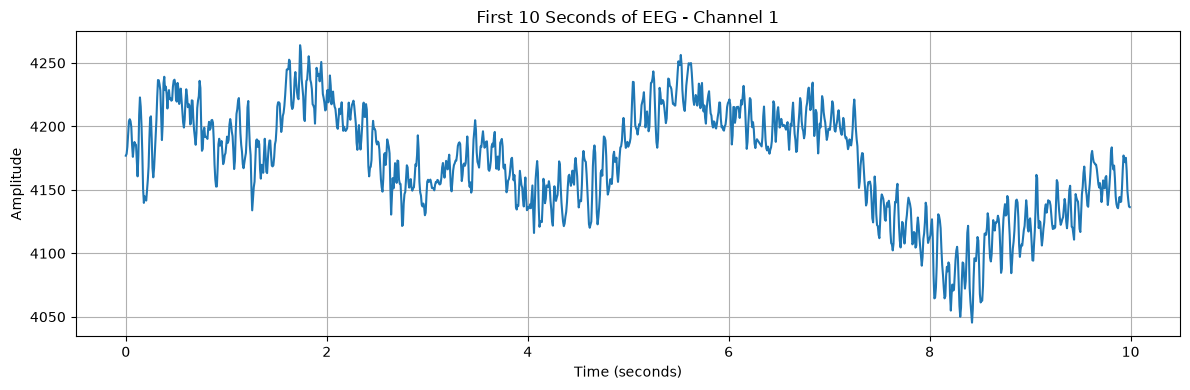

In [14]:
import matplotlib.pyplot as plt

fs = 128
seconds = 10
number_of_samples = fs * seconds

time = [i / fs for i in range(number_of_samples)]
signal = eeg[:number_of_samples, 0]
plt.figure(figsize=(12, 4))
plt.plot(time, signal)

plt.title('First 10 Seconds of EEG - Channel 1')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print('Missing values:', np.isnan(eeg).sum())
print('Infinite values:', np.isinf(eeg).sum())

print('Standard deviation per channel:')
print(np.std(eeg, axis=0))

Missing values: 0
Infinite values: 0
Standard deviation per channel:
[ 64.52425045  25.65748979  55.10914237 134.33208593  20.02887734
  21.6041806   20.47828037  30.05275846  43.77260736 176.62951339
  88.234679    47.42971957  35.09144277  22.0243253 ]


#### Load Dataset

In [18]:
signals = []
labels = []
subjects = []

for file_path in sorted(data_dir.glob('*.mat')):
    data = loadmat(file_path)
    eeg = data['EEGData']

    if file_path.name.startswith('ASub'):
        label = 1
    elif file_path.name.startswith('ACSub'):
        label = 0
    else:
        print('Unknown file:', file_path.name)
        continue

    signals.append(eeg)
    labels.append(label)
    subjects.append(file_path.stem)

signals = np.array(signals)
labels = np.array(labels)

print("Signals shape:", signals.shape)
print("Labels shape:", labels.shape)
print("Anxiety participants:", np.sum(labels == 1))
print("Control participants:", np.sum(labels == 0))
print("First subjects:", subjects[:5])

Signals shape: (38, 38400, 14)
Labels shape: (38,)
Anxiety participants: 23
Control participants: 15
First subjects: ['ACSub1', 'ACSub10', 'ACSub11', 'ACSub12', 'ACSub13']


#### Create Windows without data leakage

In [ ]:
window_size = 4 * 128

#### Frequency-based EEG features

- [ ] Delta 1-4 Hz
- [ ] Theta 4-8 Hz
- [ ] Alpha 8-13 Hz
- [ ] Beta 13-30 Hz
- [ ] Gamma 30-45 Hz

In [ ]:
from scipy.signal import welch
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score


In [20]:
from pathlib import Path
from scipy.io import loadmat
from scipy.signal import welch
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import numpy as np

# Dataset folder
data_dir = Path(
    r"F:\pxsa\Digital-Biomarkers\Datasets\Multi-channel Wireless EEG Recordings of Young Adu"
)

fs = 128

# Frequency bands
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

features = []
labels = []
subjects = []

# Load files and extract features
for file_path in sorted(data_dir.glob("*.mat")):
    eeg = loadmat(file_path)["EEGData"]

    if file_path.name.startswith("ASub"):
        label = 1
    elif file_path.name.startswith("ACSub"):
        label = 0
    else:
        continue

    participant_features = []

    # Calculate PSD for each channel
    for channel in range(eeg.shape[1]):
        frequencies, power = welch(
            eeg[:, channel],
            fs=fs,
            nperseg=256
        )

        # Calculate mean power in every frequency band
        for low, high in bands.values():
            band_power = power[
                (frequencies >= low) & (frequencies < high)
            ].mean()

            participant_features.append(band_power)

    features.append(participant_features)
    labels.append(label)
    subjects.append(file_path.stem)

X = np.array(features)
y = np.array(labels)

print("Feature matrix shape:", X.shape)
print("Label shape:", y.shape)

# Leave-One-Subject-Out evaluation
loo = LeaveOneOut()

true_labels = []
predicted_labels = []

for train_index, test_index in loo.split(X):
    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)[0]

    true_labels.append(y_test[0])
    predicted_labels.append(prediction)

accuracy = accuracy_score(true_labels, predicted_labels)
balanced_accuracy = balanced_accuracy_score(
    true_labels,
    predicted_labels
)

print("LOSO accuracy:", accuracy)
print("LOSO balanced accuracy:", balanced_accuracy)


Feature matrix shape: (38, 70)
Label shape: (38,)
LOSO accuracy: 0.4473684210526316
LOSO balanced accuracy: 0.4391304347826087
